In [8]:
import subprocess
import sys

libraries = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'requests', 'yfinance', 'scipy']

for lib in libraries:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '--user', '--quiet'])
    print(f'✅ {lib} installed')



✅ pandas installed
✅ numpy installed
✅ matplotlib installed
✅ seaborn installed
✅ requests installed
✅ yfinance installed
✅ scipy installed


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

STOCKS = {
    'Deutsche Bank':   'DBK.DE',
    'Commerzbank':     'CBK.DE',
    'Deutsche Boerse': 'DB1.DE',
    'DAX Index':       '^GDAXI'
}

START_DATE = '2015-01-01'
END_DATE   = '2024-12-31'

print('Fetching stock data...')
prices = pd.DataFrame()

for name, ticker in STOCKS.items():
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    prices[name] = df['Close']
    print(f'  ✅ {name} — {len(df)} trading days')

prices.dropna(how='all', inplace=True)
prices.index = pd.to_datetime(prices.index)

returns = prices.pct_change().dropna()

print(f'\n✅ prices shape: {prices.shape}')
print(f'✅ returns shape: {returns.shape}')
print(f'\nFirst 3 rows of prices:')
print(prices.head(3))

Fetching stock data...
  ✅ Deutsche Bank — 2542 trading days
  ✅ Commerzbank — 2542 trading days
  ✅ Deutsche Boerse — 2542 trading days
  ✅ DAX Index — 2537 trading days

✅ prices shape: (2542, 4)
✅ returns shape: (2541, 4)

First 3 rows of prices:
            Deutsche Bank  Commerzbank  Deutsche Boerse    DAX Index
Date                                                                
2015-01-02      18.939257    10.173262        46.329556  9764.730469
2015-01-05      18.166838     9.842019        46.235725  9473.160156
2015-01-06      17.934364     9.755805        46.016788  9469.660156


In [24]:
print('=' * 60)


print('\n Average Annual Price (GROUP BY Year)')
print('-' * 50)
yearly_avg = prices.copy()
yearly_avg['Year'] = yearly_avg.index.year
yearly_avg = yearly_avg.groupby('Year').mean().round(2)
print(yearly_avg)

print('\n Best & Worst Year for Deutsche Bank')
print('-' * 50)
db_yearly = yearly_avg[['Deutsche Bank']].copy()
db_yearly['YoY Change'] = db_yearly['Deutsche Bank'].pct_change() * 100
db_yearly = db_yearly.dropna()
best_year  = db_yearly['YoY Change'].idxmax()
worst_year = db_yearly['YoY Change'].idxmin()
print(f'Best year:  {best_year} ({db_yearly.loc[best_year, "YoY Change"]:.2f}%)')
print(f'Worst year: {worst_year} ({db_yearly.loc[worst_year, "YoY Change"]:.2f}%)')

print('\n Days where Deutsche Bank closed above €10 (WHERE)')
print('-' * 50)
above_10 = prices[prices['Deutsche Bank'] > 10][['Deutsche Bank']]
print(f'Trading days above €10: {len(above_10)} out of {len(prices)} total')
print(f'Percentage: {len(above_10)/len(prices)*100:.1f}%')

print('\n Correlation between all stocks')
print('-' * 50)
print(prices.corr().round(3))


 Average Annual Price (GROUP BY Year)
--------------------------------------------------
      Deutsche Bank  Commerzbank  Deutsche Boerse  DAX Index
Year                                                        
2015          20.81        10.13            60.68   10961.50
2016          11.31         6.38            60.67   10195.65
2017          13.54         9.30            75.15   12434.59
2018           9.45         9.08            96.16   12269.59
2019           6.27         5.76           111.30   12108.67
2020           7.02         4.20           131.09   12339.14
2021           9.58         5.42           130.40   15209.81
2022           9.06         6.87           152.37   13874.85
2023           9.73         9.66           161.09   15670.83
2024          14.09        13.40           192.08   18387.82

 Best & Worst Year for Deutsche Bank
--------------------------------------------------
Best year:  2024 (44.81%)
Worst year: 2016 (-45.65%)

 Days where Deutsche Bank closed ab

In [11]:
returns = prices.pct_change().dropna()

print('=' * 60)
print('RISK & RETURN METRICS')
print('=' * 60)

metrics = pd.DataFrame()
metrics['Annual Return (%)']    = returns.mean() * 252 * 100
metrics['Annual Volatility (%)'] = returns.std() * np.sqrt(252) * 100
metrics['Sharpe Ratio']          = metrics['Annual Return (%)'] / metrics['Annual Volatility (%)']
metrics['Max Drawdown (%)']      = (prices / prices.cummax() - 1).min() * 100
metrics['Best Day (%)']          = returns.max() * 100
metrics['Worst Day (%)']         = returns.min() * 100

print(metrics.round(2).to_string())

RISK & RETURN METRICS
                 Annual Return (%)  Annual Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Best Day (%)  Worst Day (%)
Deutsche Bank                 6.11                  39.05          0.16            -82.46         12.90         -18.44
Commerzbank                  12.57                  41.50          0.30            -78.97         18.02         -21.21
Deutsche Boerse              17.95                  22.23          0.81            -36.97         13.10         -11.84
DAX Index                     8.91                  19.18          0.46            -38.78         10.98         -12.24


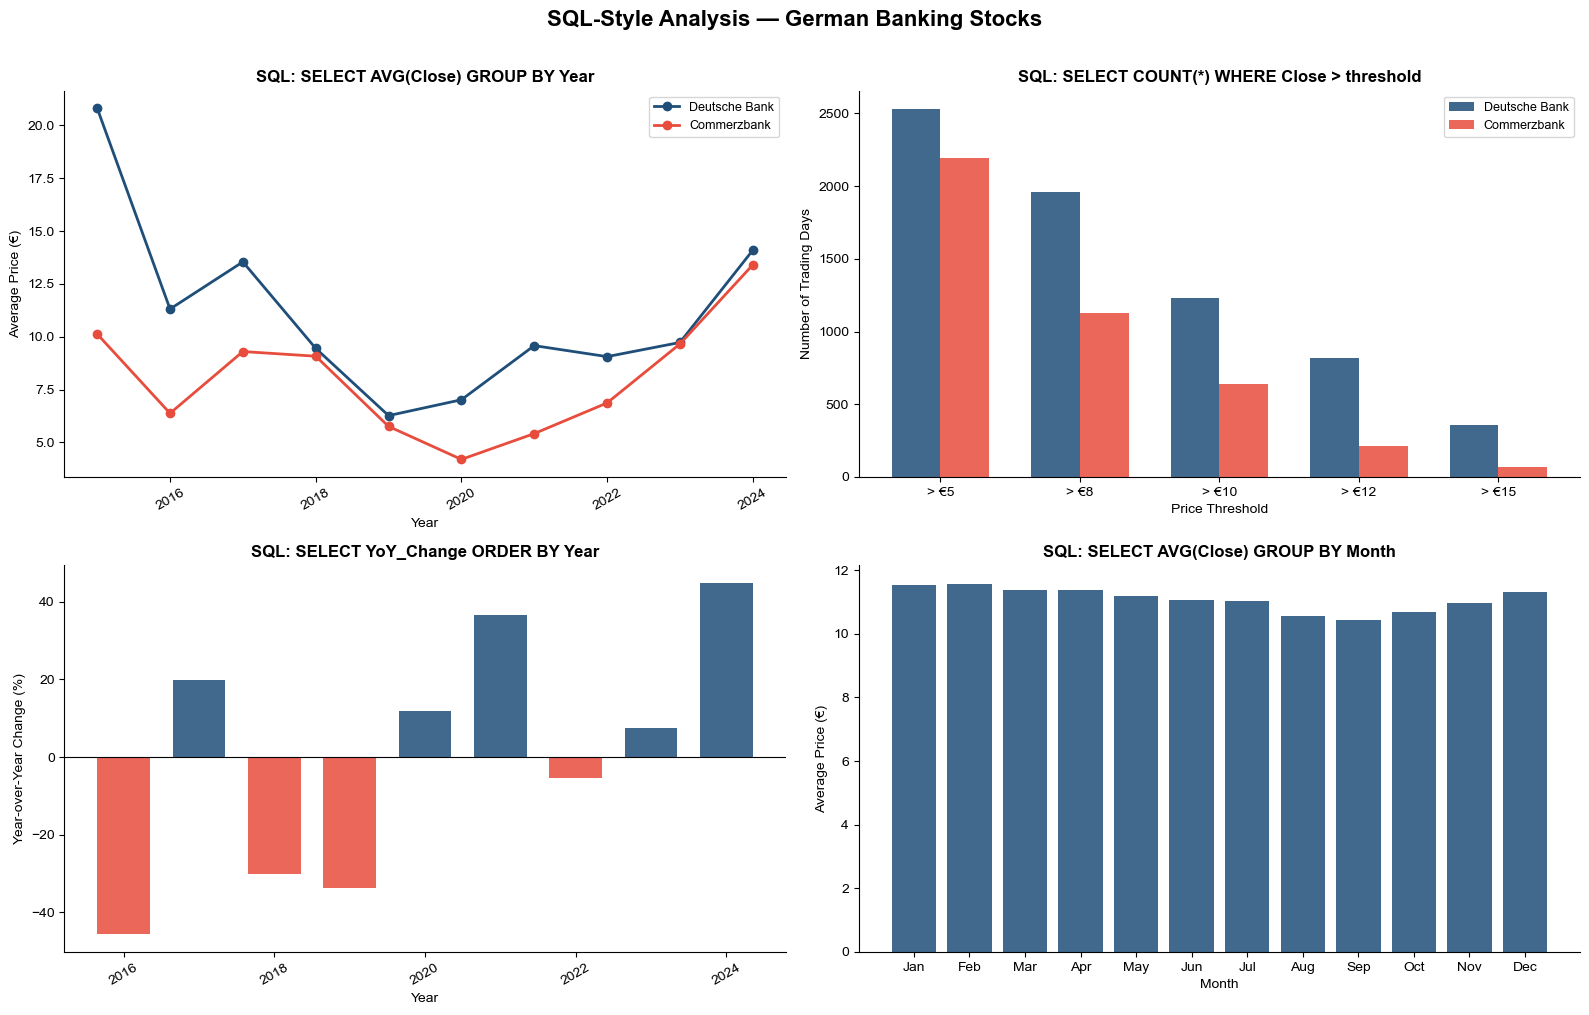

✅ SQL Analysis plot saved


In [23]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
yearly_avg = prices.copy()
yearly_avg['Year'] = yearly_avg.index.year
yearly_avg = yearly_avg.groupby('Year').mean().round(2)

for col, color in zip(['Deutsche Bank', 'Commerzbank'], ['#1F4E79', '#E74C3C']):
    ax1.plot(yearly_avg.index, yearly_avg[col], marker='o',
             label=col, color=color, linewidth=2)

ax1.set_title('SQL: SELECT AVG(Close) GROUP BY Year', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Price (€)')
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', rotation=30)

ax2 = axes[0, 1]
thresholds = [5, 8, 10, 12, 15]
counts = {name: [len(prices[prices[name] > t]) for t in thresholds]
          for name in ['Deutsche Bank', 'Commerzbank']}

x = np.arange(len(thresholds))
width = 0.35
ax2.bar(x - width/2, counts['Deutsche Bank'], width,
        label='Deutsche Bank', color='#1F4E79', alpha=0.85)
ax2.bar(x + width/2, counts['Commerzbank'], width,
        label='Commerzbank', color='#E74C3C', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f'> €{t}' for t in thresholds])
ax2.set_title('SQL: SELECT COUNT(*) WHERE Close > threshold', fontsize=12, fontweight='bold')
ax2.set_xlabel('Price Threshold')
ax2.set_ylabel('Number of Trading Days')
ax2.legend(fontsize=9)

ax3 = axes[1, 0]
yoy = yearly_avg['Deutsche Bank'].pct_change().dropna() * 100
colors_yoy = ['#1F4E79' if v >= 0 else '#E74C3C' for v in yoy]
ax3.bar(yoy.index, yoy.values, color=colors_yoy, alpha=0.85, width=0.7)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.set_title('SQL: SELECT YoY_Change ORDER BY Year', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Year-over-Year Change (%)')
ax3.tick_params(axis='x', rotation=30)

ax4 = axes[1, 1]
monthly = prices['Deutsche Bank'].copy()
monthly_avg = monthly.groupby(monthly.index.month).mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
ax4.bar(month_names, monthly_avg.values, color='#1F4E79', alpha=0.85)
ax4.set_title('SQL: SELECT AVG(Close) GROUP BY Month', fontsize=12, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Average Price (€)')

plt.suptitle('SQL-Style Analysis — German Banking Stocks',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_sql_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SQL Analysis plot saved')

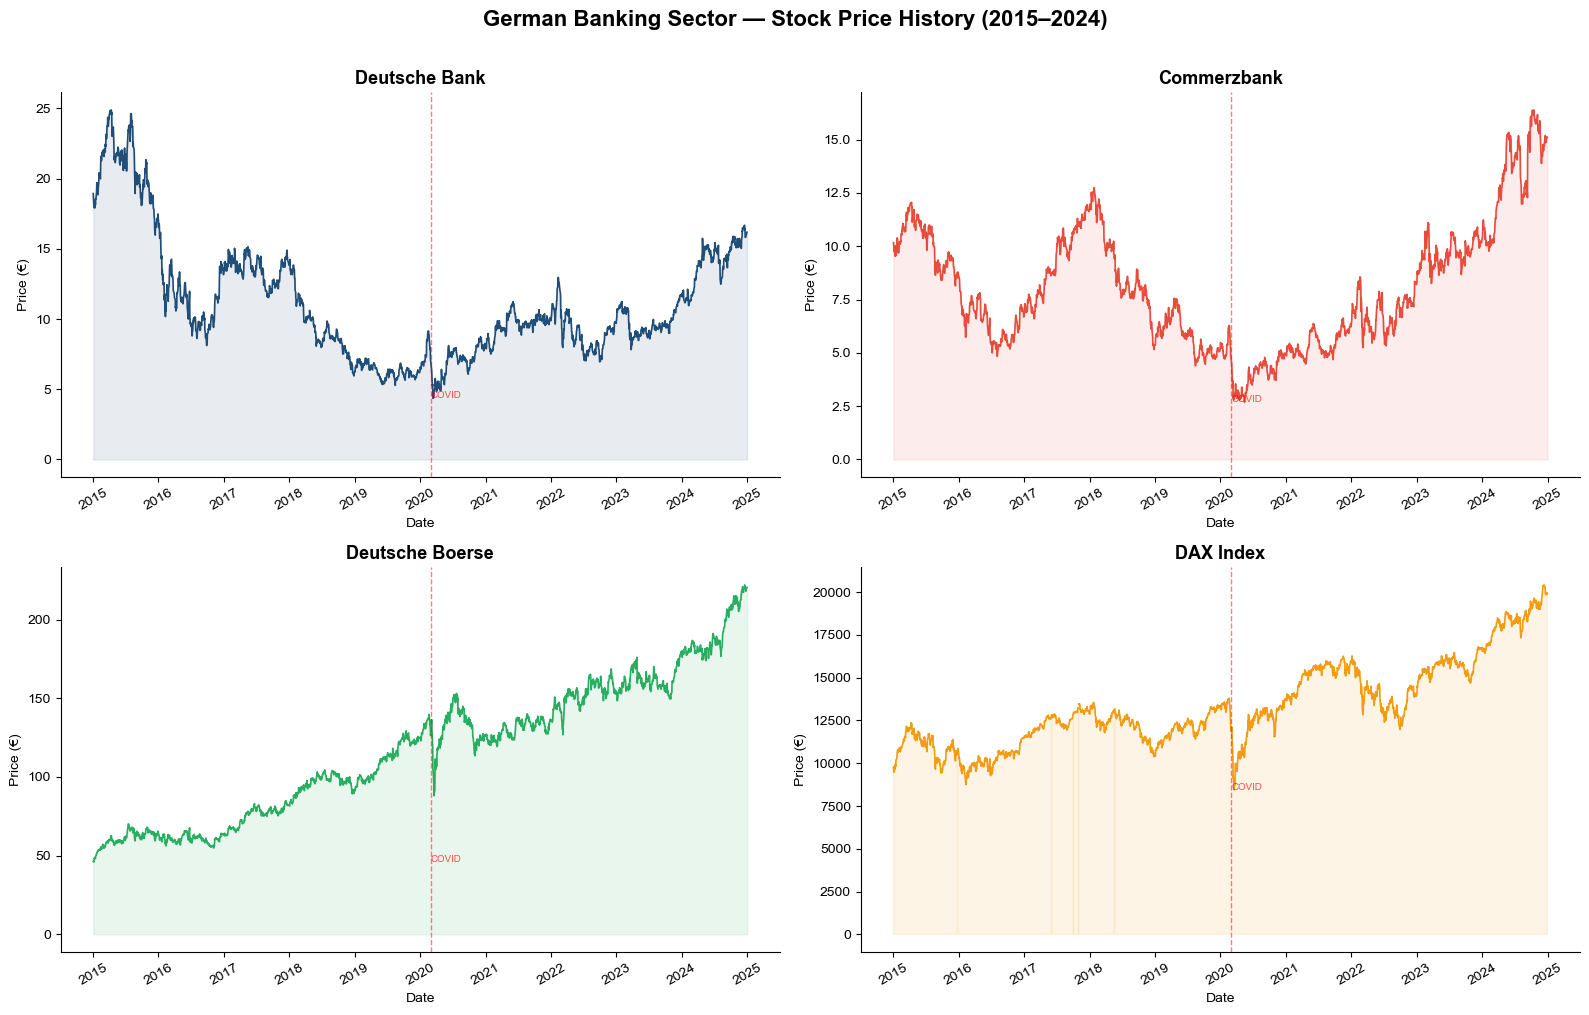

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = ['#1F4E79', '#E74C3C', '#27AE60', '#F39C12']

for i, (name, color) in enumerate(zip(STOCKS.keys(), colors)):
    ax = axes[i]
    ax.plot(prices.index, prices[name], color=color, linewidth=1.2)
    ax.fill_between(prices.index, prices[name], alpha=0.1, color=color)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Price (€)', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    
    
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.annotate('COVID', xy=(pd.Timestamp('2020-03-01'), prices[name].min()),
                fontsize=7, color='red', alpha=0.7)

plt.suptitle('German Banking Sector — Stock Price History (2015–2024)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot1_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

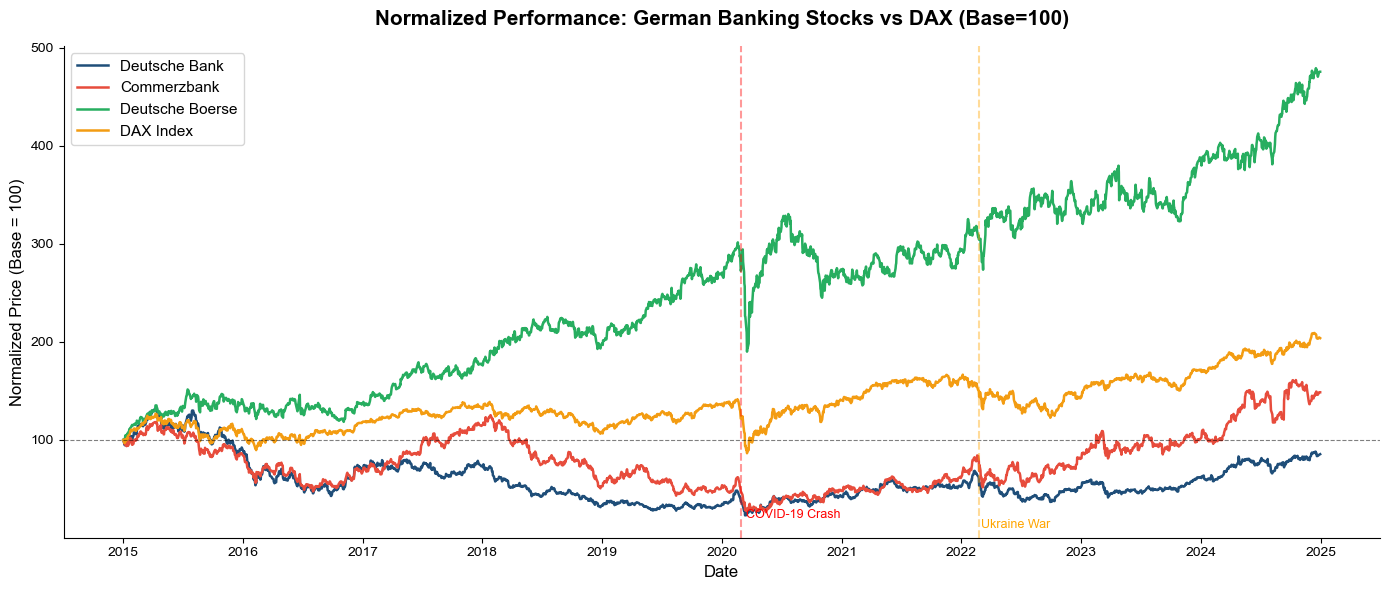

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1F4E79', '#E74C3C', '#27AE60', '#F39C12']

normalized = prices / prices.iloc[0] * 100

for name, color in zip(STOCKS.keys(), colors):
    ax.plot(normalized.index, normalized[name],
            label=name, color=color, linewidth=1.8)

ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)


ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.4)
ax.annotate('COVID-19 Crash', xy=(pd.Timestamp('2020-03-15'), 20),
            fontsize=9, color='red')

ax.axvline(pd.Timestamp('2022-02-24'), color='orange', linestyle='--', alpha=0.4)
ax.annotate('Ukraine War', xy=(pd.Timestamp('2022-03-01'), 10),
            fontsize=9, color='orange')

ax.set_title('Normalized Performance: German Banking Stocks vs DAX (Base=100)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (Base = 100)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('plot2_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

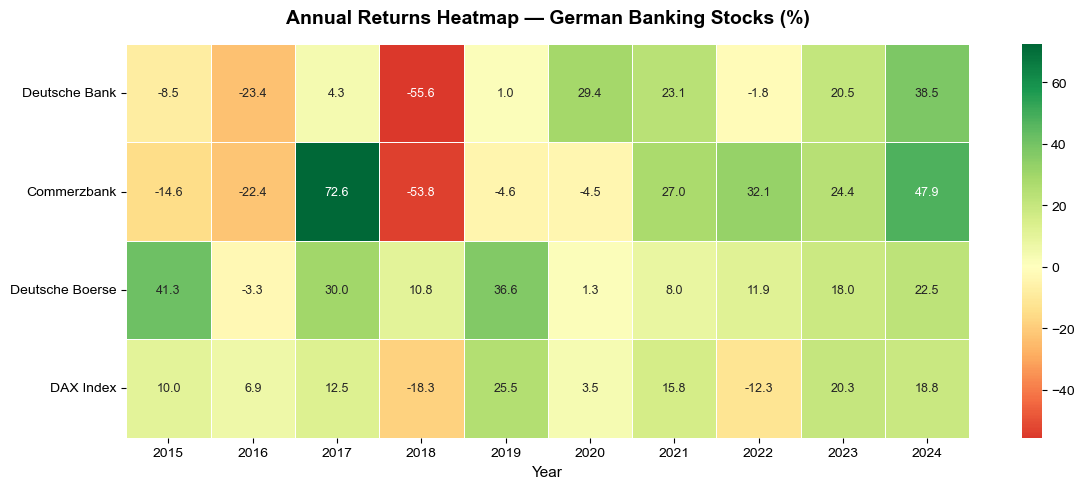

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

annual_returns = returns.copy()
annual_returns['Year'] = annual_returns.index.year
annual_pivot = annual_returns.groupby('Year').apply(
    lambda x: (1 + x).prod() - 1
) * 100
annual_pivot = annual_pivot.drop(columns=['Year'], errors='ignore')

sns.heatmap(annual_pivot.T, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})

ax.set_title('Annual Returns Heatmap — German Banking Stocks (%)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('plot3_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

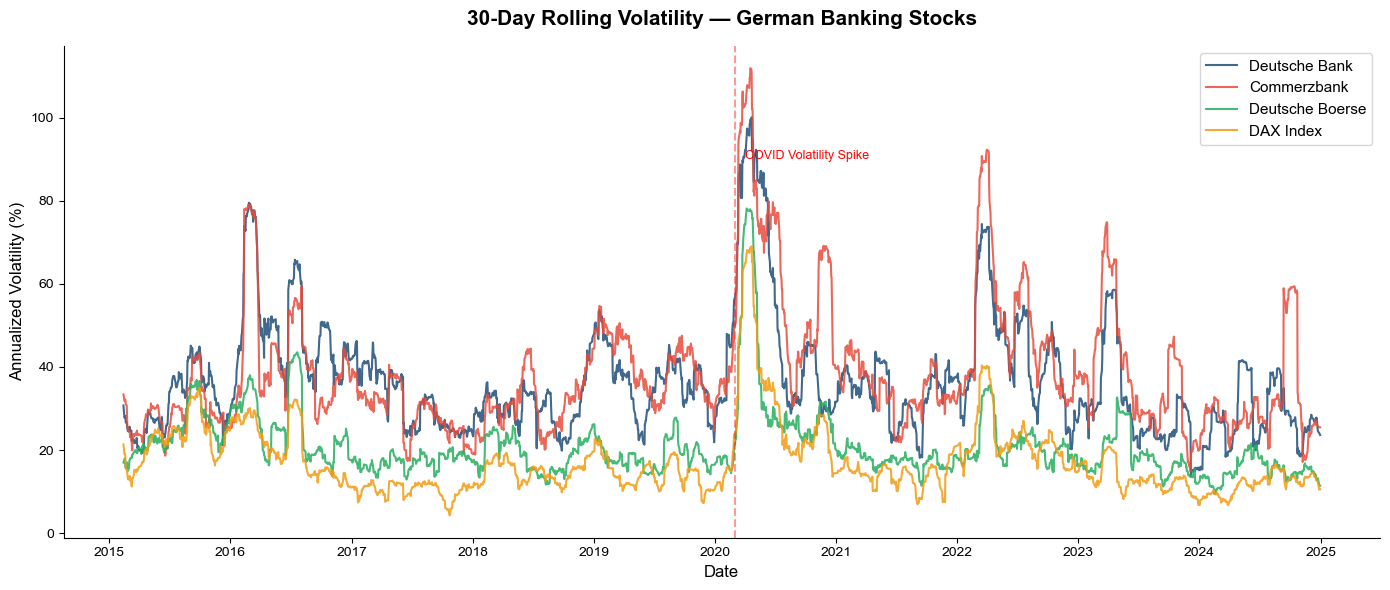

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1F4E79', '#E74C3C', '#27AE60', '#F39C12']
rolling_vol = returns.rolling(window=30).std() * np.sqrt(252) * 100

for name, color in zip(STOCKS.keys(), colors):
    ax.plot(rolling_vol.index, rolling_vol[name],
            label=name, color=color, linewidth=1.5, alpha=0.85)

ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.4)
ax.annotate('COVID Volatility Spike', xy=(pd.Timestamp('2020-04-01'), 
            rolling_vol['Deutsche Bank'].max() * 0.9),
            fontsize=9, color='red')

ax.set_title('30-Day Rolling Volatility — German Banking Stocks',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('plot4_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

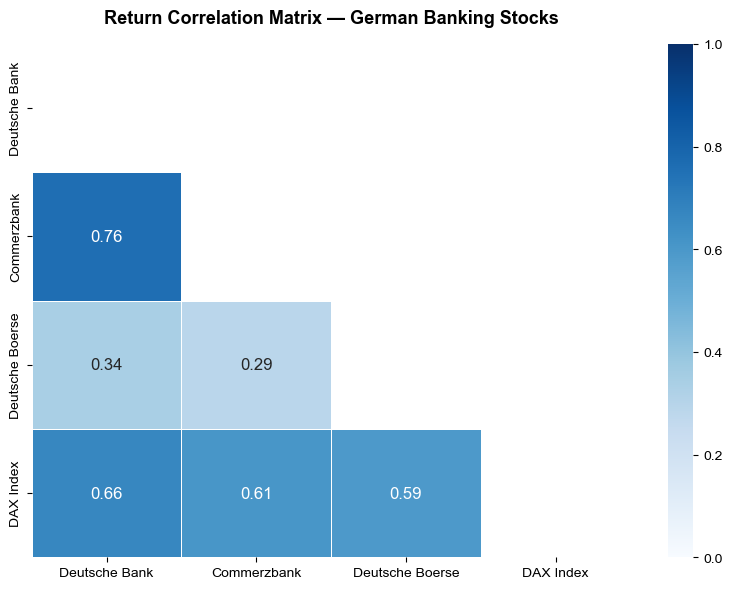

In [17]:
returns = prices.pct_change().dropna()

fig, ax = plt.subplots(figsize=(8, 6))

corr = returns.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 12}, mask=mask)

ax.set_title('Return Correlation Matrix — German Banking Stocks',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

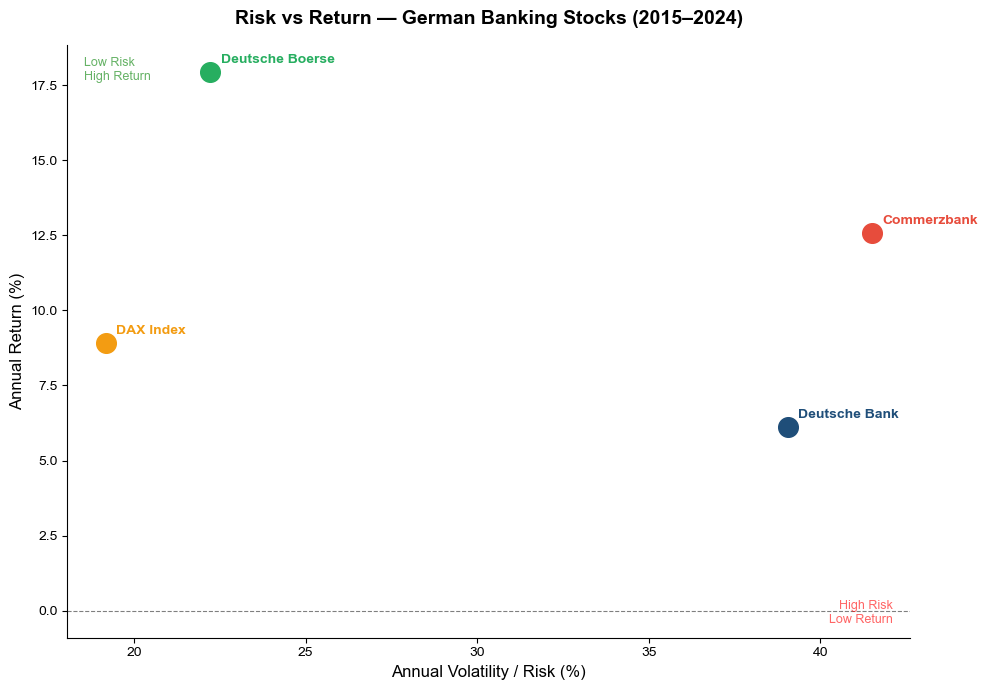

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1F4E79', '#E74C3C', '#27AE60', '#F39C12']
annual_ret  = returns.mean() * 252 * 100
annual_vol  = returns.std() * np.sqrt(252) * 100

for name, color in zip(STOCKS.keys(), colors):
    ax.scatter(annual_vol[name], annual_ret[name],
               color=color, s=200, zorder=5)
    ax.annotate(name,
                xy=(annual_vol[name], annual_ret[name]),
                xytext=(annual_vol[name] + 0.3, annual_ret[name] + 0.3),
                fontsize=10, color=color, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Risk vs Return — German Banking Stocks (2015–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annual Volatility / Risk (%)', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)

ax.text(0.02, 0.98, 'Low Risk\nHigh Return', transform=ax.transAxes,
        fontsize=9, color='green', va='top', alpha=0.6)
ax.text(0.98, 0.02, 'High Risk\nLow Return', transform=ax.transAxes,
        fontsize=9, color='red', va='bottom', ha='right', alpha=0.6)

plt.tight_layout()
plt.savefig('plot6_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print('=' * 65)
print('   GERMAN BANKING SECTOR ANALYSIS')
print('=' * 65)

annual_ret = returns.mean() * 252 * 100
annual_vol = returns.std() * np.sqrt(252) * 100
sharpe     = annual_ret / annual_vol
max_dd     = (prices / prices.cummax() - 1).min() * 100

print(f'\n{"Stock":<20} {"Return":>10} {"Volatility":>12} {"Sharpe":>8} {"Max DD":>10}')
print('-' * 65)

for name in STOCKS.keys():
    print(f'{name:<20} {annual_ret[name]:>9.2f}% {annual_vol[name]:>11.2f}% '
          f'{sharpe[name]:>8.2f} {max_dd[name]:>9.2f}%')

print(f'\n📌 Key Observations:')
best  = annual_ret.idxmax()
worst = annual_ret.idxmin()
print(f'   Best performer:  {best} ({annual_ret[best]:.2f}% annual return)')
print(f'   Worst performer: {worst} ({annual_ret[worst]:.2f}% annual return)')
print(f'   Most volatile:   {annual_vol.idxmax()} ({annual_vol.max():.2f}%)')
print(f'   Least volatile:  {annual_vol.idxmin()} ({annual_vol.min():.2f}%)')

print(f'\n📌 COVID-19 Impact (March 2020):')
covid_drop = prices.loc['2020-03-01':'2020-03-31'].pct_change().sum() * 100
for name in STOCKS.keys():
    print(f'   {name:<20}: {covid_drop[name]:.2f}% in March 2020')
print('=' * 65)

   GERMAN BANKING SECTOR ANALYSIS

Stock                    Return   Volatility   Sharpe     Max DD
-----------------------------------------------------------------
Deutsche Bank             6.11%       39.05%     0.16    -82.46%
Commerzbank              12.57%       41.50%     0.30    -78.97%
Deutsche Boerse          17.95%       22.23%     0.81    -36.97%
DAX Index                 8.91%       19.18%     0.46    -38.78%

📌 Key Observations:
   Best performer:  Deutsche Boerse (17.95% annual return)
   Worst performer: Deutsche Bank (6.11% annual return)
   Most volatile:   Commerzbank (41.50%)
   Least volatile:  DAX Index (19.18%)

📌 COVID-19 Impact (March 2020):
   Deutsche Bank       : -18.99% in March 2020
   Commerzbank         : -34.79% in March 2020
   Deutsche Boerse     : -11.40% in March 2020
   DAX Index           : -15.32% in March 2020
